# Dataset Selection
Choose one Kaggle dataset related to:

1. Business / Sales
2. Healthcare
3. Finance
4. Marketing
5. Customer behavior
6. AI/ML datasets

# Data Loading & Inspection

**Task 1:** Load dataset using Pandas.

In [231]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/kaggle/input/datasets/ak0212/uae-cancer-patient-dataset/_cancer_dataset_uae.csv")

**Task 2:**

Display:


* first 10 rows
* dataset shape
* column names
* data types


Questions:

1. How many rows and columns exist?
2. Which columns are categorical vs numeric?

In [232]:
# task 2

In [233]:
df.head(10)

,Patient_ID,Age,Gender,Nationality,Emirate,Diagnosis_Date,Cancer_Type,Cancer_Stage,Treatment_Type,Treatment_Start_Date,Hospital,Primary_Physician,Outcome,Death_Date,Cause_of_Death,Smoking_Status,Comorbidities,Ethnicity,Weight,Height
0,PAT000001,69,Female,Emirati,Umm Al Quwain,2020-11-30,Liver,II,Radiation,2020-12-04,Sheikh Khalifa Hospital,Dr. VO41,Recovered,NaN,NaN,Non-Smoker,NaN,European,61,157
1,PAT000002,32,Male,Emirati,Umm Al Quwain,2015-10-10,Leukemia,III,Surgery,2015-11-05,Dubai Hospital,Dr. SM31,Recovered,NaN,NaN,Smoker,NaN,South Asian,80,175
2,PAT000003,89,Male,Emirati,Abu Dhabi,2018-02-13,Liver,III,Radiation,2018-08-03,Zayed Military Hospital,Dr. BC7,Under Treatment,NaN,NaN,Non-Smoker,NaN,South Asian,50,175
3,PAT000004,78,Female,Emirati,Abu Dhabi,2022-02-04,Lung,III,Radiation,2022-03-13,Cleveland Clinic Abu Dhabi,Dr. TC14,Recovered,NaN,NaN,Former Smoker,NaN,African,44,155
4,PAT000005,38,Female,Emirati,Fujairah,2019-12-03,Pancreatic,II,Chemotherapy,2020-02-29,Sheikh Khalifa Hospital,Dr. YS37,Recovered,NaN,NaN,Former Smoker,NaN,East Asian,101,160
5,PAT000006,41,Female,Emirati,Abu Dhabi,2015-02-10,Breast,I,Surgery,2015-04-21,Dubai Hospital,Dr. ZL30,Recovered,NaN,NaN,Smoker,Hypertension,European,59,176
6,PAT000007,20,Male,Emirati,Ras Al Khaimah,2023-02-27,Ovarian,IV,Chemotherapy,2023-05-15,Sheikh Khalifa Hospital,Dr. AL45,Recovered,NaN,NaN,Non-Smoker,Hypertension,Arab,66,155
7,PAT000008,39,Male,Expatriate,Sharjah,2018-04-05,Breast,I,Surgery,2018-08-10,Sheikh Khalifa Hospital,Dr. IL20,Under Treatment,NaN,NaN,Non-Smoker,NaN,South Asian,27,189
8,PAT000009,70,Female,Emirati,Umm Al Quwain,2022-12-12,Lung,III,Immunotherapy,2023-05-29,Dubai Hospital,Dr. KH33,Deceased,2024-12-22 00:00:00,Cancer,Non-Smoker,NaN,South Asian,60,162
9,PAT000010,19,Female,Emirati,Dubai,2018-05-29,Breast,I,Surgery,2018-07-25,Cleveland Clinic Abu Dhabi,Dr. GX45,Recovered,NaN,NaN,Non-Smoker,NaN,East Asian,73,180


In [234]:
df.shape

# 1000 rows and 20 columns

(10000, 20)

In [235]:
df.dtypes

# 20 columns in which 17 are categorical and 3 are numeric

Patient_ID              object
Age                      int64
Gender                  object
Nationality             object
Emirate                 object
Diagnosis_Date          object
Cancer_Type             object
Cancer_Stage            object
Treatment_Type          object
Treatment_Start_Date    object
Hospital                object
Primary_Physician       object
Outcome                 object
Death_Date              object
Cause_of_Death          object
Smoking_Status          object
Comorbidities           object
Ethnicity               object
Weight                   int64
Height                   int64
dtype: object

In [236]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Nationality', 'Emirate',
       'Diagnosis_Date', 'Cancer_Type', 'Cancer_Stage', 'Treatment_Type',
       'Treatment_Start_Date', 'Hospital', 'Primary_Physician', 'Outcome',
       'Death_Date', 'Cause_of_Death', 'Smoking_Status', 'Comorbidities',
       'Ethnicity', 'Weight', 'Height'],
      dtype='object')

# Data Cleaning

**Task 3**

Check missing values.

Questions:

1. Which columns contain missing values?

In [237]:
# task 3

In [238]:
df.isna().sum()

# Death_Dates,Cause_of_Death and Comorbidities have mising values

Patient_ID                 0
Age                        0
Gender                     0
Nationality                0
Emirate                    0
Diagnosis_Date             0
Cancer_Type                0
Cancer_Stage               0
Treatment_Type             0
Treatment_Start_Date       0
Hospital                   0
Primary_Physician          0
Outcome                    0
Death_Date              9008
Cause_of_Death          9008
Smoking_Status             0
Comorbidities           4047
Ethnicity                  0
Weight                     0
Height                     0
dtype: int64

**Task 4**

Handle missing data using one of the following:

* mean
* median
* mode
* dropping rows

Explain why you chose that method.

In [239]:
# task 4

In [240]:
# Death Date : Patients who survived will naturally have no death date, so marking it as Not Applicable keeps the data meaningful.
df['Death_Date'] = df['Death_Date'].fillna('Not Applicable')

# Cause of Death : Some deaths may not have a recorded cause. Filling with Unknown prevents data loss while keeping the dataset consistent.
df['Cause_of_Death'] = df['Cause_of_Death'].fillna('Unknown')

# Comorbidities : Mode imputation works well for categorical variables because it replaces missing values with the most common condition in the dataset.
df['Comorbidities'] = df['Comorbidities'].fillna(df['Comorbidities'].mode()[0])

**Task 5** 

Check duplicate rows and remove them

In [241]:
df.duplicated().sum()

np.int64(0)

# Feature Engineering

**Task 6**

Create one new feature using NumPy or Pandas.

Questions:

Why is this feature useful?

In [242]:
# Creating BMI feature
df['BMI'] = df['Weight'] / ((df['Height']/100) ** 2)
df['BMI']

# BMI helps identify whether a patient is underweight, normal weight, overweight, or obese, which can influence cancer risk and treatment outcomes.

0       24.747454
1       26.122449
2       16.326531
3       18.314256
4       39.453125
          ...    
9995    19.486961
9996    32.000000
9997    33.792470
9998    18.255524
9999    18.710949
Name: BMI, Length: 10000, dtype: float64

# Statistical Analysis

**Task 7**

Calculate:

* mean
* median
* standard deviation
* min
* max

Questions:

Which column has the highest variability?

In [243]:
df.describe()
# Age has the highest varience in the dataset because it is more spread out from the mean point. The higher the standard deviation the higher the variability

,Age,Weight,Height,BMI
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,53.539700,69.550000,169.347500,24.503744
std,20.757324,14.933339,10.070118,6.038208
min,18.000000,18.000000,131.000000,5.673505
25%,36.000000,60.000000,163.000000,20.305175
50%,53.000000,70.000000,169.000000,24.128792
75%,72.000000,80.000000,176.000000,28.384802
max,89.000000,122.000000,208.000000,53.374656


**Task 8**

Use NumPy to compute statistics.

In [244]:
np.mean(df["BMI"])

np.float64(24.503743539896906)

In [245]:
np.std(df["BMI"])

6.037905859434953

# Univariate Visualization

Create 3 plots.

**Task 9**

Histogram

Question:

Is the distribution normal, skewed, or uniform?

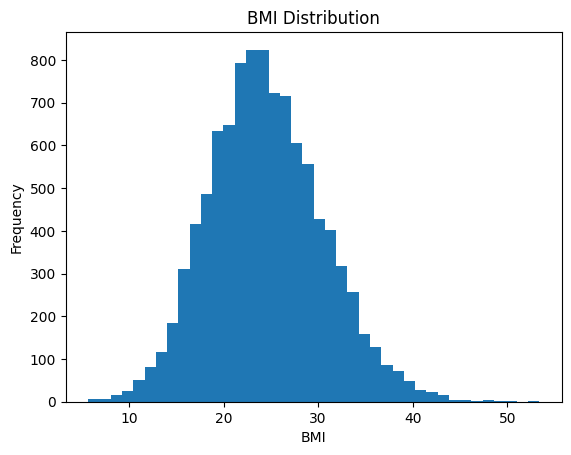

In [246]:
plt.hist(df['BMI'], bins=40)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

# It shows a little right skew distribution

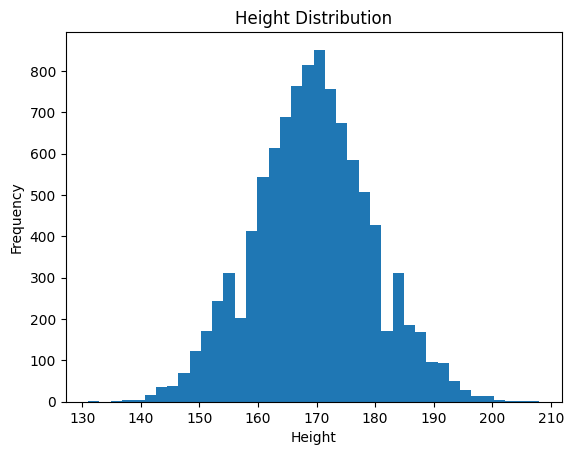

In [247]:
plt.hist(df['Height'], bins=40)

plt.title("Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")

plt.show()

# It shows a normal distribution

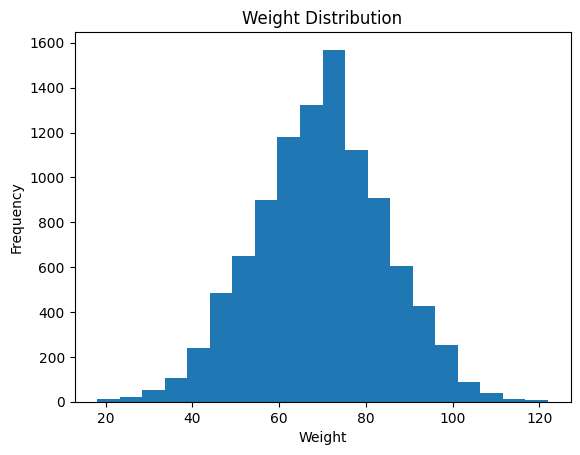

In [248]:
plt.hist(df['Weight'], bins=20)

plt.title("Weight Distribution")
plt.xlabel("Weight")
plt.ylabel("Frequency")

plt.show()

# It shows a normal distribution

**Task 10**

Boxplot

Question:

Are there any outliers?

<Axes: xlabel='BMI'>

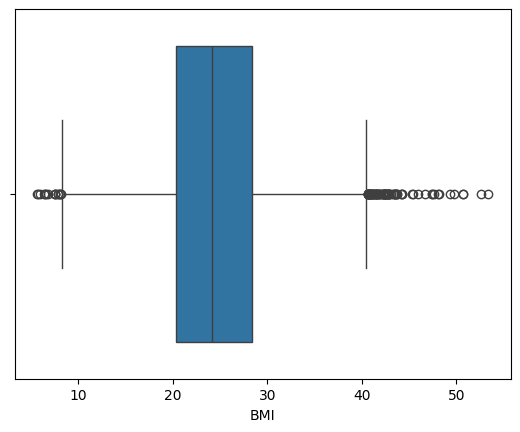

In [249]:
sns.boxplot(x=df["BMI"])

# The lower outliers represent patients with extremely low BMI, possibly underweight or due to severe illness.

# The upper outliers represent patients with very high BMI, indicating obesity.

**Task 11**

Countplot

Question:

Which category appears the most?

<Axes: xlabel='Gender', ylabel='count'>

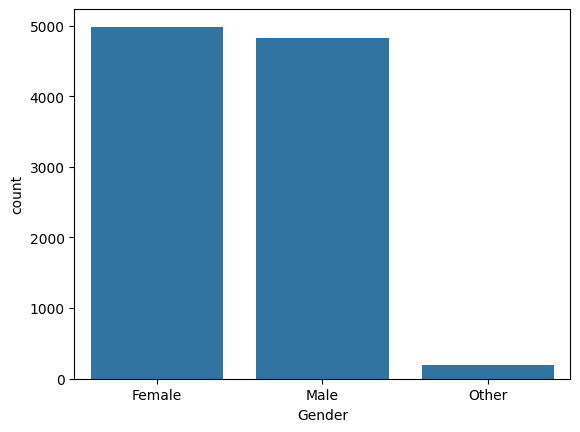

In [267]:
sns.countplot(x="Gender", data=df)

# This graph show the distribution of cancer patients based on gender
# Female patients appears the most in these categories

# Bivariate Analysis

**Task 12**

Scatter plot

Question:

Is there correlation between the variables?

<Axes: xlabel='Weight', ylabel='Height'>

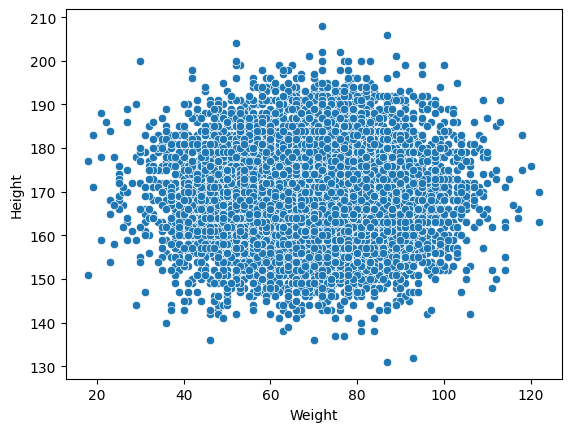

In [269]:
sns.scatterplot(x="W", y="Height", data=df)

# This graph shows the correlation of paitents height and weight which has positive but little correlation and has no patterns 

In [252]:
df['Height'].corr(df['Weight'])

np.float64(0.013775604770866463)

In [253]:
df[["Height","Weight","Age","BMI"]].corr()

,Height,Weight,Age,BMI
Height,1.000000,0.013776,-0.005786,-0.473740
Weight,0.013776,1.000000,0.009409,0.865668
Age,-0.005786,0.009409,1.000000,0.010965
BMI,-0.473740,0.865668,0.010965,1.000000


**Task 13**

Barplot

Question:

Which category has the highest average value?

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Liver'),
  Text(1, 0, 'Leukemia'),
  Text(2, 0, 'Lung'),
  Text(3, 0, 'Pancreatic'),
  Text(4, 0, 'Breast'),
  Text(5, 0, 'Ovarian'),
  Text(6, 0, 'Prostate'),
  Text(7, 0, 'Colorectal')])

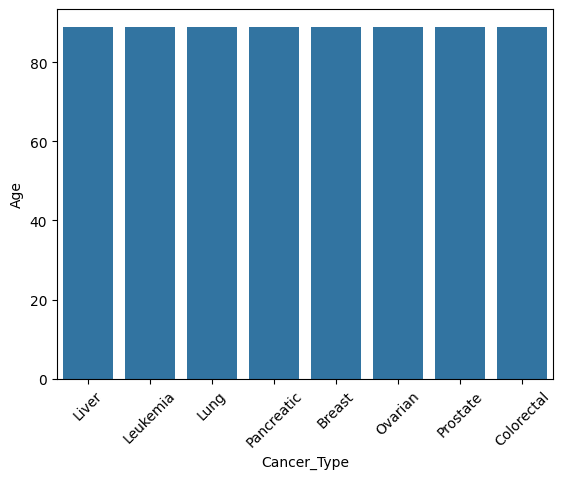

In [254]:
sns.barplot(x="Cancer_Type", y="Age", data=df, estimator=np.max)
plt.xticks(rotation=45)


In [255]:
highest_avg_age = df.groupby("Cancer_Type")["Age"].mean().idxmax()
print("Cancer type with highest average age:", highest_avg_age)

Cancer type with highest average age: Colorectal


**Task 14**

Line plot (if time or sequence exists)

Question:

What trend do you observe?

In [256]:
import datetime as dt

# Convert the 'Death_Date' and 'Treatment_Start_Date' column to datetime format
df['Diagnosis_Date'] = pd.to_datetime(df['Diagnosis_Date'], format='%Y-%m-%d')
df['Treatment_Start_Date'] = pd.to_datetime(df['Treatment_Start_Date'], format='%Y-%m-%d')
df[['Diagnosis_Date','Treatment_Start_Date']]

,Diagnosis_Date,Treatment_Start_Date
0,2020-11-30,2020-12-04
1,2015-10-10,2015-11-05
2,2018-02-13,2018-08-03
3,2022-02-04,2022-03-13
4,2019-12-03,2020-02-29
...,...,...
9995,2016-01-21,2016-04-03
9996,2018-12-06,2019-03-23
9997,2016-06-11,2016-10-21
9998,2018-11-12,2019-02-05


<Axes: xlabel='Diagnosis_Date', ylabel='Age'>

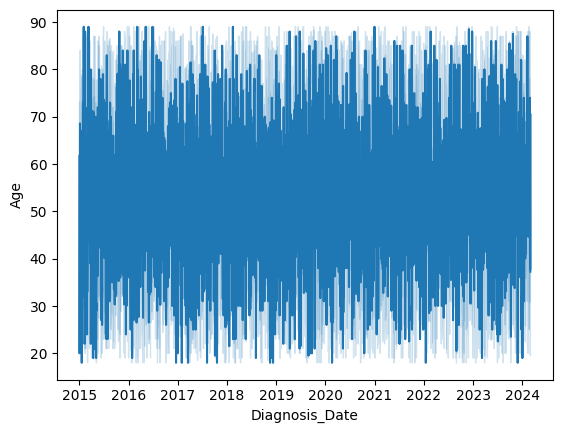

In [257]:
sns.lineplot(x="Diagnosis_Date", y="Age", data=df)

# Multivariate Visualization

**Task 15**

Correlation Heatmap

Questions:

1. Which variables are highly correlated?
2. Why might that happen?

<Axes: >

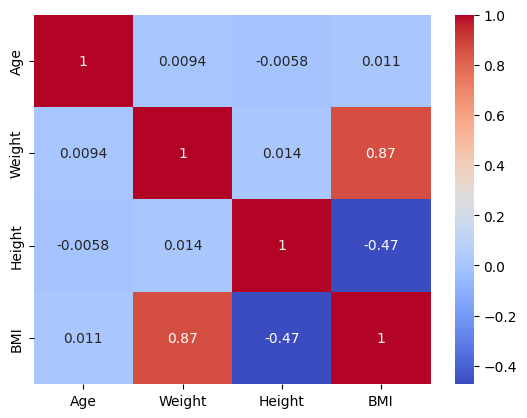

In [258]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")

# Correlation between BMI and weight is the most highest and positive because as the weight increases BMI of a patient also increases

**Task 16**

Pairplot

Question:

Which variables appear related?

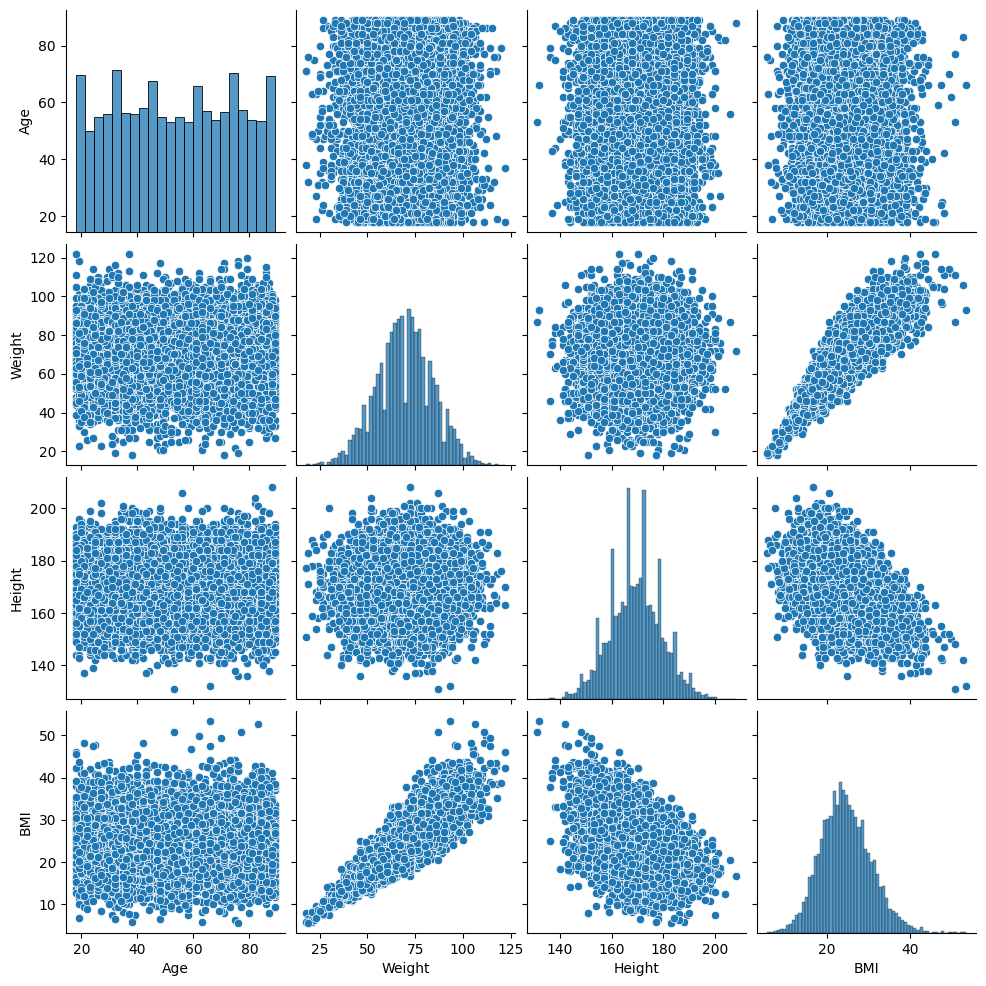

In [259]:
sns.pairplot(df)

# Weight and BMI has positive relation

# Advanced Visualization

**Task 17**

Scatter with multiple dimensions

Question:

What additional insights does color and size provide?

<Axes: xlabel='Age', ylabel='Weight'>

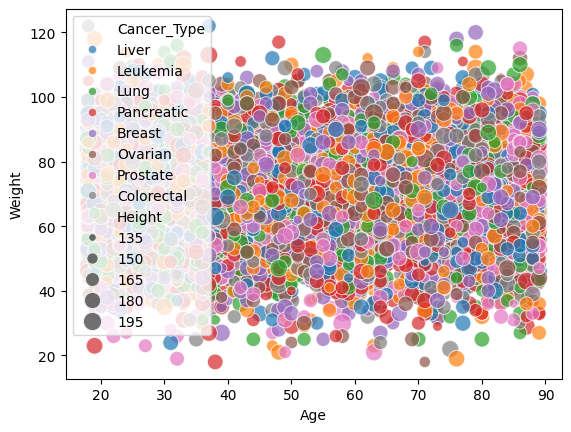

In [262]:
sns.scatterplot(
    x="Age",
    y="Weight",
    size="Height",           # bubble size
    hue="Cancer_Type",       # color by Cancer_Type
    sizes=(20, 200),         # min and max bubble size
    data=df,
    alpha=0.7                # make points slightly transparent
)

# Here height shows bubble size and color represents cancer type in the graph

# Insights

**Task 18**

Write 5 data insights.

Examples:

* Variable X strongly correlates with Y
* Category A has highest average sales
* Distribution of revenue is highly skewed
* Outliers exist in price column
* Customers in region X behave differently

# Insights
*  Highest rate of cancer found based on average age is colorectal cancer
* Weight has the strongest positive correlation with BMI
* Height has the strongest negative correlation with BMI
* Female patient are the most diagnosed patient based on Gender distribution
* BMI,Height and Weight has normal distribution with little or no skew
* BMI has outliers where lower outliers show low BMI rate means patient is skinny and higher outliers shows high BMI rate meaning patient is obese 